 In this task, you will use the following dataset to compare the performance of Logistic Regression VS a Simple Feedforward Neural Network (FFNN) in detecting whether news articles are fake or real.

> Dataset: https://www.kaggle.com/datasets/shyakanobledavid/david-ozil

# **Data Exploration**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyakanobledavid/david-ozil")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'david-ozil' dataset.
Path to dataset files: /kaggle/input/david-ozil


In [3]:
import pandas as pd

# Load the combined dataset
df = pd.read_csv(f'{path}/fake_news_data.csv')

# Map 'Label' column to numerical values
df['label'] = df['Label'].map({'fake': 0, 'real': 1})

# Rename 'Article_content' to 'content' to match the intended column name
df['content'] = df['Article_content']

# Drop original 'Label', 'Topic', and 'Article_content' columns as they are no longer needed
df = df.drop(columns=['Label', 'Topic', 'Article_content'])

print('Dataset shape:', df.shape)
print('Class distribution:')
print(df['label'].value_counts())
print('\nFirst 5 rows of the processed dataset:')
print(df.head())

Dataset shape: (46097, 2)
Class distribution:
label
0    42243
1     3854
Name: count, dtype: int64

First 5 rows of the processed dataset:
   label                                            content
0      1  القدس المحتلة- لن يتمكن المقدسي سامي درويش في ...
1      1  طهران- منذ الهجوم الإسرائيلي على القنصلية الإي...
2      1  غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...
3      1  نابلس- لليوم الثاني على التوالي، تتعرض قرية دو...
4      1  بريتوريا- تقدمت اللجنة المستقلة للانتخابات في ...


In [4]:
import re
from nltk.corpus import stopwords
import nltk

# Download NLTK resources if not already downloaded
try:
    stopwords.words('arabic')
except LookupError:
    nltk.download('stopwords')


def clean_arabic_text(text):
    text = re.sub(r'[\u064B-\u0652]', '', text) # Arabic diacritics
    text = re.sub(r'[\!"\#\$\%\&\(\)\*\+\,\-\.\/\:\;\<\=\>\?\@\[\\\]\^\_\`\{\|\}\~]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'[إأآ]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ئ', 'ء', text)
    text = re.sub(r'ؤ', 'ء', text)
    text = re.sub(r'ى', 'ي', text)

    stop_words = set(stopwords.words('arabic'))
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

# Apply the cleaning function to the 'content' column
df['cleaned_content'] = df['content'].apply(clean_arabic_text)

print('Arabic content cleaning complete.')
print('\nFirst 5 rows with cleaned content:')
print(df[['content', 'cleaned_content']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Arabic content cleaning complete.

First 5 rows with cleaned content:
                                             content  \
0  القدس المحتلة- لن يتمكن المقدسي سامي درويش في ...   
1  طهران- منذ الهجوم الإسرائيلي على القنصلية الإي...   
2  غادر المحامي الفلسطيني راجي صوراني قطاع غزة رف...   
3  نابلس- لليوم الثاني على التوالي، تتعرض قرية دو...   
4  بريتوريا- تقدمت اللجنة المستقلة للانتخابات في ...   

                                     cleaned_content  
0  القدس المحتله يتمكن المقدسي سامي درويش موسم ال...  
1  طهران الهجوم الاسراءيلي علي القنصليه الايرانيه...  
2  المحامي الفلسطيني راجي صوراني قطاع غزه رفقه عا...  
3  نابلس لليوم الثاني علي التوالي، تتعرض قريه دوم...  
4  بريتوريا تقدمت اللجنه المستقله للانتخابات جنوب...  


In [5]:
import numpy as np

def tokenize_text(text):
    """Tokenizes text into words."""
    return text.split()

def average_embedding(texts, model):
    """Computes the average word embedding for a list of texts."""
    # If the model has a .wv (word_vectors) attribute, use it for accessing embeddings
    word_vectors = model.wv if hasattr(model, 'wv') else model

    # Get the embedding dimension from the model
    # This assumes all vectors in the model have the same dimension
    # Fallback to a default if the model doesn't expose vector_size directly
    if hasattr(model, 'vector_size'):
        vector_size = model.vector_size
    elif hasattr(word_vectors, 'vector_size'):
        vector_size = word_vectors.vector_size
    else:
        # Try to infer from the first word's vector if available
        if len(word_vectors.index_to_key) > 0:
            vector_size = word_vectors[word_vectors.index_to_key[0]].shape[0]
        else:
            # Default or raise an error if vector_size cannot be determined
            print("Warning: Could not determine vector_size. Assuming 100.")
            vector_size = 100 # Or handle as an error

    averaged_embeddings = []
    for text in texts:
        tokens = tokenize_text(text)
        valid_embeddings = []
        for word in tokens:
            if word in word_vectors:
                valid_embeddings.append(word_vectors[word])

        if valid_embeddings:
            averaged_embeddings.append(np.mean(valid_embeddings, axis=0))
        else:
            # If no words are found in the model, return a zero vector
            averaged_embeddings.append(np.zeros(vector_size))
    return np.array(averaged_embeddings)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
RANDOM_STATE = 42

X = df['cleaned_content'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 36877 | Test size: 9220


# **Tokenization for FFNN**

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)

word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 147098


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def build_ffnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)), # Explicitly define the input layer
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Q1) Perform fake news detection using Logistic Regression and TF-IDF embeddings.

In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Initialize and fit TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
tfidf_lr.fit(X_train_tfidf, y_train)

y_pred_tfidf = tfidf_lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, y_pred_tfidf)
lr_f1 = f1_score(y_test, y_pred_tfidf)

print("TF-IDF + Logistic Regression")
print("Accuracy:", round(lr_acc, 4))
print("F1-score:", round(lr_f1, 4))
print()
print(classification_report(y_test, y_pred_tfidf, target_names=["fake", "real"]))

TF-IDF + Logistic Regression
Accuracy: 0.9922
F1-score: 0.9514

              precision    recall  f1-score   support

        fake       0.99      1.00      1.00      8449
        real       0.99      0.91      0.95       771

    accuracy                           0.99      9220
   macro avg       0.99      0.96      0.97      9220
weighted avg       0.99      0.99      0.99      9220



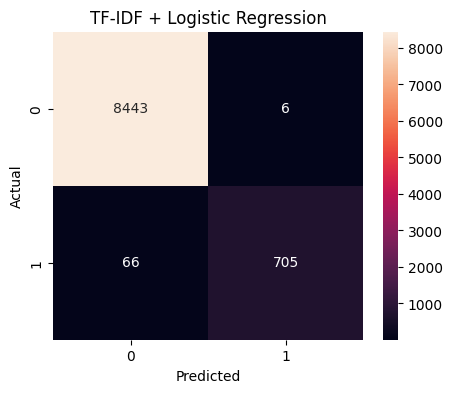

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('TF-IDF + Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Q2) Perform fake news detection using FFNN with GloVe Embeddings.

In [11]:
!pip install gensim
import numpy as np
import gensim.downloader as api
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
from tensorflow.keras.models import Sequential

# Load GloVe Embeddings
print('Loading GloVe (glove-wiki-gigaword-100)…')
glove_wv = api.load('glove-wiki-gigaword-100')   # 100-dim
GLOVE_DIM = 100 # Define GLOVE_DIM
print('GloVe loaded. Vocab size:', len(glove_wv))

# Create Embedding Matrix
embedding_matrix = np.zeros((MAX_WORDS, GLOVE_DIM))
for word, i in word_index.items():
    if i < MAX_WORDS:
        try:
            embedding_matrix[i] = glove_wv[word]
        except KeyError:
            # Words not found in embedding index will be all-zeros.
            pass

# Build the FFNN model with Embedding layer
ffnn_glove_model = Sequential([
    Embedding(MAX_WORDS, GLOVE_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    GlobalAveragePooling1D(), # or Flatten(), depending on the desired architecture
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ffnn_glove_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ffnn_glove_model.summary()

# Train the model
print('\nTraining FFNN + GloVe…')
history_ffnn_glove = ffnn_glove_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

# Evaluate the model
loss, glove_acc = ffnn_glove_model.evaluate(X_test_pad, y_test, verbose=0)
y_pred_glove = (ffnn_glove_model.predict(X_test_pad) > 0.5).astype("int32")

# Assuming f1_score and classification_report are imported elsewhere
# If not, you might need to import them here or in an earlier cell
from sklearn.metrics import f1_score, classification_report

glove_f1 = f1_score(y_test, y_pred_glove)

print("\nFFNN + GloVe Embeddings")
print("Accuracy:", round(glove_acc, 4))
print("F1-score:", round(glove_f1, 4))
print()
print(classification_report(y_test, y_pred_glove, target_names=["fake", "real"]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.1 MB/s eta 0:00:00
Loading GloVe (glove-wiki-gigaword-100)…
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Vocab size: 400000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)


Training FFNN + GloVe…
Epoch 1/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9448 - loss: 0.1919 - val_accuracy: 0.9520 - val_loss: 0.1703
Epoch 2/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9493 - loss: 0.1724 - val_accuracy: 0.9521 - val_loss: 0.1687
Epoch 3/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9496 - loss: 0.1710 - val_accuracy: 0.9472 - val_loss: 0.1693
Epoch 4/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9506 - loss: 0.1702 - val_accuracy: 0.9524 - val_loss: 0.1664
Epoch 5/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9503 - loss: 0.1679 - val_accuracy: 0.9523 - val_loss: 0.1675
Epoch 6/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9504 - loss: 0.1673 - val_accuracy: 0.9476 - val_loss: 0.1677
Epoch 7/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9510 - loss: 0.1678 - val_accuracy: 0.9525 - val_loss: 0.1680
Epoch 8/10
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 

 # Q3) Perform fake news detection using FFNN with FastText Embeddings.

In [12]:
import gensim.downloader as api
from sklearn.metrics import accuracy_score, f1_score

ft_model = api.load('fasttext-wiki-news-subwords-300')

X_train_fast = average_embedding(X_train, ft_model)
X_test_fast  = average_embedding(X_test,  ft_model)

fast_ffnn = build_ffnn(300)

fast_ffnn.fit(
    X_train_fast,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

fast_preds = (fast_ffnn.predict(X_test_fast) > 0.5).astype(int)

fast_acc = accuracy_score(y_test, fast_preds)
fast_f1  = f1_score(y_test, fast_preds)

print('Accuracy:', fast_acc)
print('F1-score:', fast_f1)


[==================================================] 100.0% 958.5/958.4MB downloaded
Epoch 1/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9224 - loss: 0.2079 - val_accuracy: 0.9498 - val_loss: 0.1527
Epoch 2/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9509 - loss: 0.1333 - val_accuracy: 0.9688 - val_loss: 0.1091
Epoch 3/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9628 - loss: 0.1055 - val_accuracy: 0.9734 - val_loss: 0.0888
Epoch 4/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9671 - loss: 0.0931 - val_accuracy: 0.9764 - val_loss: 0.0776
Epoch 5/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9716 - loss: 0.0828 - val_accuracy: 0.9669 - val_loss: 0.0939
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9720173535791757
F1-score: 0.8464285714285714


 # Q4) Perform fake news detection using FFNN with Word2Vec Embeddings.

In [13]:
import gensim.downloader as api
from sklearn.metrics import accuracy_score, f1_score

w2v_model = api.load('word2vec-google-news-300')

X_train_w2v = average_embedding(X_train, w2v_model)
X_test_w2v  = average_embedding(X_test,  w2v_model)

w2v_ffnn = build_ffnn(300)

w2v_ffnn.fit(
    X_train_w2v,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

w2v_preds = (w2v_ffnn.predict(X_test_w2v) > 0.5).astype(int)

w2v_acc = accuracy_score(y_test, w2v_preds)
w2v_f1  = f1_score(y_test, w2v_preds)

print('Accuracy:', w2v_acc)
print('F1-score:', w2v_f1)


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Epoch 1/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9284 - loss: 0.2633 - val_accuracy: 0.9273 - val_loss: 0.2497
Epoch 2/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9308 - loss: 0.2466 - val_accuracy: 0.9292 - val_loss: 0.2469
Epoch 3/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9319 - loss: 0.2442 - val_accuracy: 0.9276 - val_loss: 0.2502
Epoch 4/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9327 - loss: 0.2412 - val_accuracy: 0.9281 - val_loss: 0.2504
Epoch 5/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9331 - loss: 0.2409 - val_accuracy: 0.9306 - val_loss: 0.2520
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.9319956616052061
F1-score: 0.38226600985221676


 # Q5) Perform fake news detection using FFNN with AraVec V2 Embeddings.

In [14]:
from gensim.models import Word2Vec
import kagglehub
from sklearn.metrics import accuracy_score, f1_score # Ensure these are imported

# Download latest version
path = kagglehub.dataset_download("hadeerkhalednabil/full-grams-cbow-100-twitter")

print("Path to dataset files:", path)

# Load the AraVec model from the downloaded path, correcting the file extension and name to match the dataset.
aravec_model = Word2Vec.load(f'{path}/full_grams_cbow_100_twitter.mdl')

X_train_aravec = average_embedding(X_train, aravec_model)
X_test_aravec = average_embedding(X_test, aravec_model)

aravec_ffnn = build_ffnn(100)

aravec_ffnn.fit(
    X_train_aravec,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

aravec_preds = (aravec_ffnn.predict(X_test_aravec) > 0.5).astype(int)

aravec_acc = accuracy_score(y_test, aravec_preds)
aravec_f1 = f1_score(y_test, aravec_preds)

print("Accuracy:", aravec_acc)
print("F1-score:", aravec_f1)

Using Colab cache for faster access to the 'full-grams-cbow-100-twitter' dataset.
Path to dataset files: /kaggle/input/full-grams-cbow-100-twitter
Epoch 1/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9634 - loss: 0.1050 - val_accuracy: 0.9826 - val_loss: 0.0468
Epoch 2/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9813 - loss: 0.0516 - val_accuracy: 0.9870 - val_loss: 0.0330
Epoch 3/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9846 - loss: 0.0420 - val_accuracy: 0.9894 - val_loss: 0.0276
Epoch 4/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9857 - loss: 0.0383 - val_accuracy: 0.9902 - val_loss: 0.0234
Epoch 5/5
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0332 - val_accuracy: 0.9894 - val_loss: 0.0263
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9876355748373102
F1-score: 0.9250985545335085


 # Q6) Print the accurcy and F1-score for all above medoels.

In [15]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression + TF-IDF',
        'FFNN + GloVe',
        'FFNN + FastText',
        'FFNN + Word2Vec',
        'FFNN + AraVec'
    ],
    'Accuracy': [
        lr_acc,
        glove_acc,
        fast_acc,
        w2v_acc,
        aravec_acc
    ],
    'F1-score': [
        lr_f1,
        glove_f1,
        fast_f1,
        w2v_f1,
        aravec_f1
    ]
})
results = results.sort_values(by='Accuracy', ascending=False)
results

,Model,Accuracy,F1-score
0,Logistic Regression + TF-IDF,0.992191,0.951417
4,FFNN + AraVec,0.987636,0.925099
2,FFNN + FastText,0.972017,0.846429
1,FFNN + GloVe,0.951844,0.675912
3,FFNN + Word2Vec,0.931996,0.382266
